In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [18]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.jo['Order_ID', 'Order_Date', 'Customer_Name', 'Product', 'Category', 'Quantity', 'Unit_Price', 'Sales', 'City']
in(dirname, filename))

/kaggle/input/datasets/corneliusozoji/sales-data/SalesData.csv


In [26]:
print(df.columns.tolist())

['Order_ID', 'Order_Date', 'Customer_Name', 'Product', 'Category', 'Quantity', 'Unit_Price', 'Sales', 'City']


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [44]:
df = pd.read_csv('/kaggle/input/datasets/corneliusozoji/sales-data/SalesData.csv')

In [45]:
df.head()

,Order_ID,Order_Date,Customer_Name,Product,Category,Quantity,Unit_Price,Sales,City
0,1001,2024-01-02,John Smith,Laptop,Electronics,2,850.0,1700.0,Lagos
1,1002,03/01/2024,Mary Johnson,Mouse,Electronics,5,25.0,125.0,Abuja
2,1003,2024/01/05,David Brown,Keyboard,Electronics,3,45.0,135.0,Kano
3,1004,06-01-2024,Sarah Wilson,Monitor,Electronics,1,220.0,220.0,Port Harcourt
4,1005,2024-01-07,NaN,Printer,Office,2,180.0,360.0,Ibadan


In [46]:
import pandas as pd

# Load dataset
df = pd.read_csv('/kaggle/input/datasets/corneliusozoji/sales-data/SalesData.csv')

# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# Remove rows with missing Customer_Name
df = df.dropna(subset=['Customer_Name'])

# Remove duplicate rows
df = df.drop_duplicates()

# Convert Order_Date to datetime
df['Order_Date'] = pd.to_datetime(df['Order_Date'], format='mixed', dayfirst=True)

# Verify data types
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 24 entries, 0 to 24
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order_ID       24 non-null     int64         
 1   Order_Date     23 non-null     datetime64[ns]
 2   Customer_Name  24 non-null     object        
 3   Product        24 non-null     object        
 4   Category       24 non-null     object        
 5   Quantity       23 non-null     object        
 6   Unit_Price     23 non-null     float64       
 7   Sales          23 non-null     float64       
 8   City           22 non-null     object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(5)
memory usage: 1.9+ KB
None


In [49]:
snapshot_date = df['Order_Date'].max() + pd.Timedelta(days=1)

In [50]:
rfm = df.groupby('Customer_Name').agg({
    'Order_Date': lambda x: (snapshot_date - x.max()).days,
    'Order_ID': 'nunique',
    'Sales': 'sum'
}).reset_index()

rfm.columns = ['Customer_Name', 'Recency', 'Frequency', 'Monetary']

rfm.head()

,Customer_Name,Recency,Frequency,Monetary
0,john smith,10.0,1,100.0
1,Alice King,14.0,1,40.0
2,Bob Scott,13.0,1,50.0
3,Chris Hall,15.0,2,2400.0
4,David Brown,8.0,2,385.0


In [52]:
rfm['R'] = pd.qcut(rfm['Recency'], 4, labels=[4, 3, 2, 1])
rfm['F'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1, 2, 3, 4])
rfm['M'] = pd.qcut(rfm['Monetary'], 4, labels=[1, 2, 3, 4])

rfm['RFM_Score'] = (
    rfm['R'].astype(str) +
    rfm['F'].astype(str) +
    rfm['M'].astype(str)
)

In [53]:
def segment_customer(row):
    r = str(row['R'])
    f = str(row['F'])

    if r == '4' and f == '4':
        return 'Loyal Customers'
    elif r == '4':
        return 'New Customers'
    elif r == '1':
        return 'Churn Risk'
    else:
        return 'Regular Customers'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

rfm.head()

,Customer_Name,Recency,Frequency,Monetary,R,F,M,RFM_Score,Segment
0,john smith,10.0,1,100.0,3,1,1,311,Regular Customers
1,Alice King,14.0,1,40.0,2,1,1,211,Regular Customers
2,Bob Scott,13.0,1,50.0,2,1,1,211,Regular Customers
3,Chris Hall,15.0,2,2400.0,2,4,4,244,Regular Customers
4,David Brown,8.0,2,385.0,3,4,3,343,Regular Customers


In [54]:
print(rfm['Segment'].value_counts())

Segment
Regular Customers    11
Churn Risk            5
New Customers         4
Loyal Customers       2
Name: count, dtype: int64


In [55]:
segment_summary = rfm.groupby('Segment').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).round(2)

print(segment_summary)

                   Recency  Frequency  Monetary
Segment                                        
Churn Risk           21.40       1.00    461.00
Loyal Customers       3.00       1.00    970.00
New Customers         3.75       1.00    697.50
Regular Customers    12.50       1.18    548.64


In [56]:
behavior = rfm.groupby('Segment').agg({
    'Recency': ['mean', 'min', 'max'],
    'Frequency': ['mean', 'min', 'max'],
    'Monetary': ['mean', 'min', 'max']
}).round(2)

print(behavior)

                  Recency             Frequency         Monetary         \
                     mean   min   max      mean min max     mean    min   
Segment                                                                   
Churn Risk          21.40  18.0  25.0      1.00   1   1   461.00 -240.0   
Loyal Customers      3.00   1.0   5.0      1.00   1   1   970.00  240.0   
New Customers        3.75   2.0   6.0      1.00   1   1   697.50  250.0   
Regular Customers   12.50   8.0  17.0      1.18   1   2   548.64    0.0   

                           
                      max  
Segment                    
Churn Risk         1700.0  
Loyal Customers    1700.0  
New Customers      1200.0  
Regular Customers  2400.0  


In [57]:
segment_counts = rfm['Segment'].value_counts()

print(segment_counts)

Segment
Regular Customers    11
Churn Risk            5
New Customers         4
Loyal Customers       2
Name: count, dtype: int64


Text(0, 0.5, 'Number of Customers')

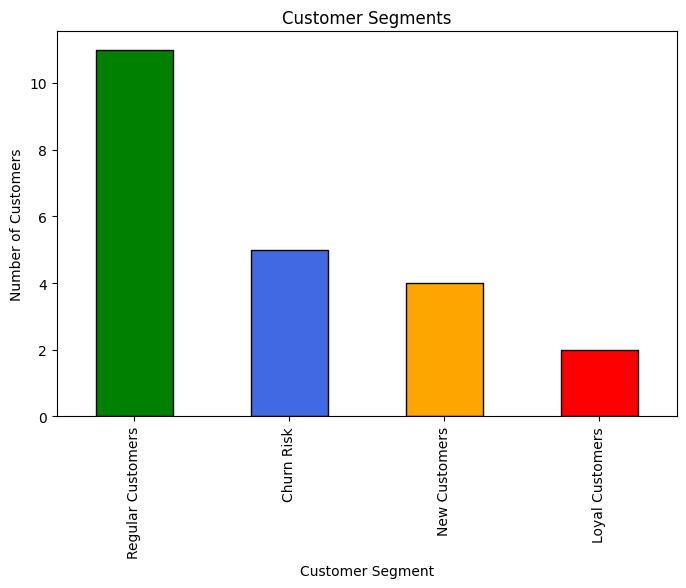

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

segment_counts.plot(
    kind='bar',
    color=['green','royalblue','orange','red'],
    edgecolor='black'
)

plt.title("Customer Segments")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")


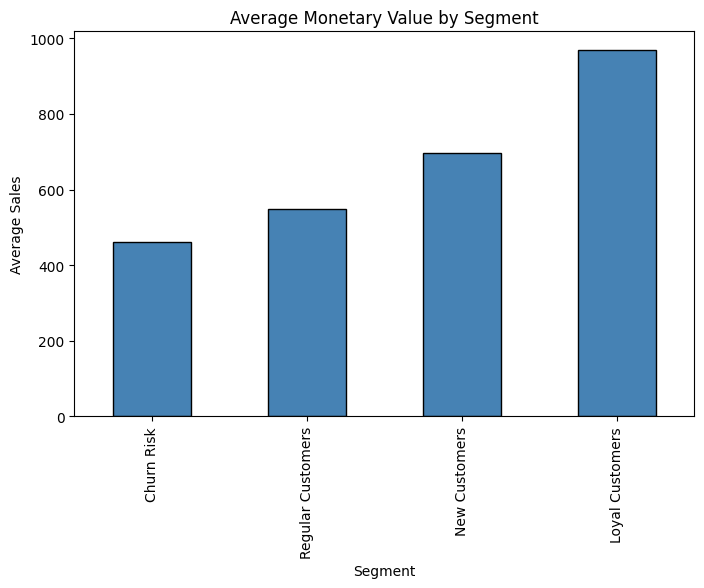

In [59]:
avg_sales = rfm.groupby('Segment')['Monetary'].mean().sort_values()

plt.figure(figsize=(8,5))

avg_sales.plot(
    kind='bar',
    color='steelblue',
    edgecolor='black'
)

plt.title("Average Monetary Value by Segment")
plt.xlabel("Segment")
plt.ylabel("Average Sales")

plt.show()

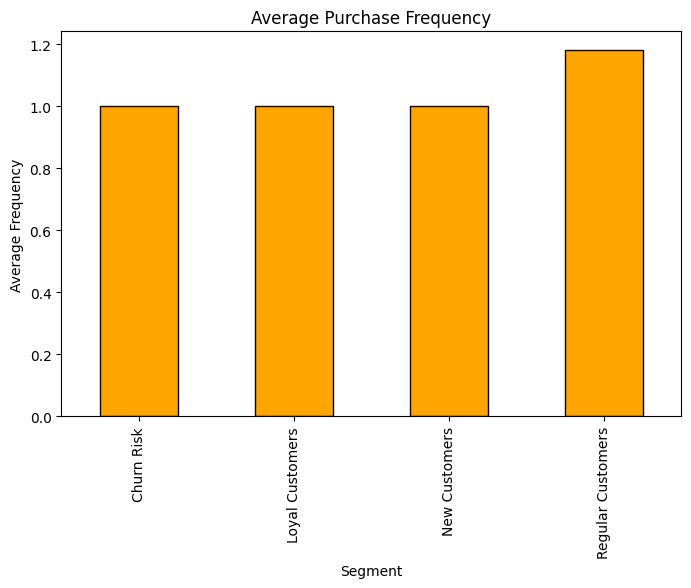

In [60]:
avg_frequency = rfm.groupby('Segment')['Frequency'].mean().sort_values()

plt.figure(figsize=(8,5))

avg_frequency.plot(
    kind='bar',
    color='orange',
    edgecolor='black'
)

plt.title("Average Purchase Frequency")
plt.xlabel("Segment")
plt.ylabel("Average Frequency")

plt.show()

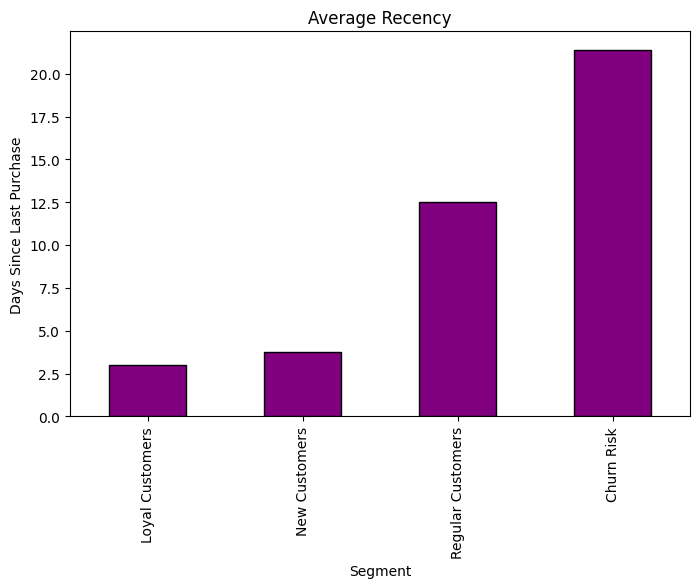

In [61]:
avg_recency = rfm.groupby('Segment')['Recency'].mean().sort_values()

plt.figure(figsize=(8,5))

avg_recency.plot(
    kind='bar',
    color='purple',
    edgecolor='black'
)

plt.title("Average Recency")
plt.xlabel("Segment")
plt.ylabel("Days Since Last Purchase")

plt.show()

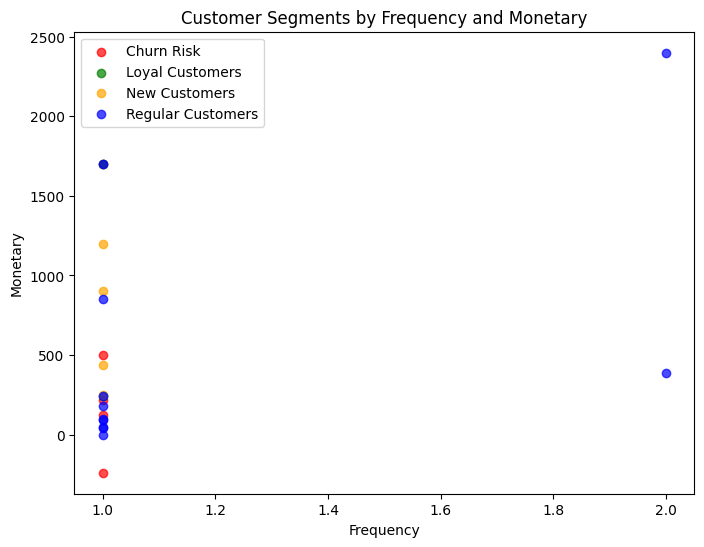

In [62]:
colors = {
    'Loyal Customers':'green',
    'Regular Customers':'blue',
    'New Customers':'orange',
    'Churn Risk':'red'
}

plt.figure(figsize=(8,6))

for segment, data in rfm.groupby('Segment'):
    plt.scatter(
        data['Frequency'],
        data['Monetary'],
        label=segment,
        color=colors.get(segment, 'gray'),
        alpha=0.7
    )

plt.xlabel("Frequency")
plt.ylabel("Monetary")
plt.title("Customer Segments by Frequency and Monetary")

plt.legend()

plt.show()


 MARKETING RECOMENDATIONS
| Customer Segment      | Marketing Strategy

| **Loyal Customers**   | Offer loyalty rewards, VIP membership, exclusive discounts, early access to new products, and referral bonuses.                                      |
| **Regular Customers** | Recommend complementary products, provide bundle offers, and send personalized promotions to increase purchase frequency.                            |
| **New Customers**     | Send welcome emails, first-repeat purchase discounts, onboarding messages, and product recommendations.                                              |
| **Churn Risk**        | Launch win-back campaigns, provide special discounts, send reminder emails, and ask for customer feedback to understand why they stopped purchasing. |

SYNTACXHUB INTERNSHIP PROJECT BY:
OZOJI CORNELIUS OGECHUKWU